 ## 🎯 Titanic Fare Prediction – Regression Analysis  
**Author**: Adeyemi Toba  
**Date**: April 3, 2025  

## 📝 Objective  
Build and evaluate regression models to predict passenger **fare** based on selected Titanic dataset features. This lab involves data cleaning, feature engineering, model training, and performance comparison using metrics like MAE, MSE, and R².



## 📝 Introduction

This project analyzes the Titanic dataset to predict the fare paid by passengers using various regression models. We aim to understand how passenger attributes such as age, gender, class, and family size influence the fare amount.

In this lab, we will:

* 💡 Explore and clean the Titanic dataset

* 🛠️ Perform feature engineering and select predictors

* 🧠 Train multiple regression models:

* Linear Regression

* Ridge Regression

* Elastic Net

* Polynomial Regression

* 📊 Evaluate model performance using MAE, MSE, and R² Score

* 📈 Visualize prediction accuracy

* ✅ Summarize findings and reflect on results

The goal is to determine which regression technique performs best for predicting fare and gain insights into what features most influence Titanic ticket pricing.




## Section 1 Imports
In the code cell below, import the necessary Python libraries for analyzing the Titanic dataset.

In [94]:
# Import pandas & numpy for data manipulation
import pandas as pd
import numpy as np

# Import matplotlib & seaborn for visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Import train_test_split for splitting data
from sklearn.model_selection import train_test_split

# Import regression models
from sklearn.linear_model import LinearRegression, Ridge, ElasticNet

# Import PolynomialFeatures for polynomial regression
from sklearn.preprocessing import PolynomialFeatures

# Import performance metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score




## ✅ Step 2: Load and Inspect the Titanic Dataset
📌 Goal: Load the dataset, check structure, and preview the data.

In [95]:
import seaborn as sns

# Load Titanic dataset
titanic = sns.load_dataset("titanic")

# Confirm it loaded properly
titanic.info()
print(titanic.head())



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB
   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0  

## ✅ 2.2 Check for Missing Values and Display Summary


In [96]:
# Check data types and non-null counts
print("📋 Dataset Info:")
titanic.info()

# Summary statistics for numeric columns
print("\n📊 Summary Statistics:")
print(titanic.describe(include='all'))

# Count of missing values per column
print("\n🔍 Missing Values by Column:")
print(titanic.isnull().sum())


📋 Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB

📊 Summary Statistics:
          survived      pclass   sex    

## 🔧 Step 3 – Data Cleaning & Feature Engineering
This step involves:

* Handling missing values

* Encoding categorical features

* Creating a new feature family_size

In [97]:
# ✅ Reload the dataset (start fresh!)
import seaborn as sns
titanic = sns.load_dataset("titanic")

# ✅ Fill missing values first
titanic['age'] = titanic['age'].fillna(titanic['age'].median())
titanic['embarked'] = titanic['embarked'].fillna(titanic['embarked'].mode()[0])
titanic['embark_town'] = titanic['embark_town'].fillna(titanic['embark_town'].mode()[0])
titanic.drop(columns=['deck'], inplace=True, errors='ignore')

# ✅ Convert 'sex' to numeric BEFORE dropping rows
titanic['sex'] = titanic['sex'].map({'male': 0, 'female': 1})

# ✅ Drop rows with missing essential features
titanic.dropna(subset=['age', 'sex', 'pclass', 'fare'], inplace=True)

# ✅ Create new feature
titanic['family_size'] = titanic['sibsp'] + titanic['parch'] + 1

# ✅ Final check
print("\n✅ Cleaned Dataset:")
titanic.info()

print("\nRemaining missing values:")
print(titanic.isnull().sum())







✅ Cleaned Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    int64   
 3   age          891 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     891 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  embark_town  891 non-null    object  
 12  alive        891 non-null    object  
 13  alone        891 non-null    bool    
 14  family_size  891 non-null    int64   
dtypes: bool(2), category(1), float64(2), int64(6), object(4)
memory usage: 86.4+ KB

Remaining missing values:
survived       0
pclass         

# Reflection 1

1. **How many data instances are there?**  
   - There are **891 data instances (rows)** in the Titanic dataset.

2. **How many features are there?**  
   - There are **15 features (columns)** in the dataset.

3. **What are the names of the features?**  
   - The features are:  
     `survived`, `pclass`, `sex`, `age`, `sibsp`, `parch`, `fare`, `embarked`,  
     `class`, `who`, `adult_male`, `deck`, `embark_town`, `alive`, `alone`.

4. **Are there any missing values?**  
   - Yes, missing values exist in the following features:  
     - `age`: 177 missing  
     - `embarked`: 2 missing  
     - `embark_town`: 2 missing  
     - `deck`: 688 missing

5. **Are there any non-numeric features?**  
   - Yes, categorical (non-numeric) features include:  
     - `sex`, `embarked`, `class`, `who`, `alive`, `embark_town`

6. **Are the data instances sorted on any attributes?**  
   - No, the dataset is **not sorted** on any attribute.

7. **What are the units of `age`?**  
   - The `age` feature is measured in **years**.

8. **What are the minimum, median, and max age?**  
   - Minimum Age: **0.42** years  
   - Median Age: **28.0** years  
   - Maximum Age: **80.0** years

9. **What two features have the highest correlation?**  
   - `parch` and `sibsp` have the highest correlation of **0.41**.

10. **Are there any categorical features that might be useful for prediction?**  
    - Yes, potentially useful categorical features include:  
      - `pclass` (Passenger class)  
      - `sex` (Gender)  
      - `embarked` (Port of Embarkation)  
      - `who` (Man, Woman, Child)



# Reflection 2 – Data Preparation and Feature Engineering

1. **How did you handle missing values?**  
   - Missing values were handled using a combination of strategies:  
     - `age`: Filled with the **median age**.  
     - `embarked` and `embark_town`: Filled with their **respective mode**.  
     - `deck`: Dropped due to having too many missing values (688 missing).  
     - Any remaining missing values in critical features like `age`, `sex`, `pclass`, and `fare` were dropped using `dropna()` to ensure data integrity.

2. **Did you create any new features?**  
   - Yes, a new feature called **`family_size`** was created using:  
     ```
     family_size = sibsp + parch + 1
     ```  
     This represents the total number of family members aboard including the passenger.

3. **Are there any features with high correlation?**  
   - Yes, the features **`parch`** and **`sibsp`** have the highest correlation of **0.41**, suggesting a relationship between the number of parents/children and siblings/spouses aboard.

4. **What is the final shape of the cleaned dataset?**  
   - The final cleaned dataset contains **891 rows** and **15 columns**, with **no missing values** in the features used for modeling.






## Section 2: Case Setup for Regression Analysis
To evaluate how different features affect the accuracy of fare prediction, we defined multiple feature sets (cases):

### 🔹 Case 1: Age Only
- **Feature(s)**: `age`
- **Rationale**: Older passengers may have more purchasing power or access to higher-class tickets.
X1 = titanic[['age']]
y1 = titanic['fare']

###  🔹 Case 2: Family Size Only
* Feature(s): family_size (engineered as sibsp + parch + 1)
* Rationale: Larger families may purchase group tickets or have lower fares due to sharing.
X2 = titanic[['family_size']]
y2 = titanic['fare']

###  🔹 Case 3: Age and Family Size
* Feature(s): age, family_size
* Rationale: Combines demographics and group travel patterns.
X3 = titanic[['age', 'family_size']]
y3 = titanic['fare']

### 🔹 Case 4: Custom Feature Combination
* Feature(s): age, family_size, pclass, sex_encoded
* Rationale: This case combines demographic, social class, and group size indicators for a more comprehensive regression model.
* First encode 'sex' to numeric
titanic['sex_encoded'] = titanic['sex'].map({'male': 0, 'female': 1})
* Define custom features
X4 = titanic[['age', 'family_size', 'pclass', 'sex_encoded']]
y4 = titanic['fare']



## 🧠 Reflection 3 – Feature Selection

1. **Why might these features affect fare?**  
   - **Age**: Older passengers may afford higher class tickets.
   - **Family Size**: Group travelers might share costs or purchase family packages.
   - **Pclass**: Indicates ticket class (1st, 2nd, 3rd) — directly related to fare.
   - **Sex**: Gender may correlate with class and survival priority, affecting fare indirectly.

---

2. **List of Available Features**:  
   - age  
   - sibsp  
   - parch  
   - fare  
   - pclass  
   - sex (encoded)  
   - embarked  
   - alone  
   - family_size (engineered)

---

3. **Which features might improve predictions and why?**  
   - **pclass**: Higher class = higher fare; a strong fare predictor.  
   - **sex** (encoded): May capture social patterns influencing fare.
   - **family_size**: Affects whether group rates were used.  
   - **age**: May relate to fare via travel class and socioeconomic status.

---

4. **How many variables are in Case 4?**  
   ✅ 4 variables: `age`, `family_size`, `pclass`, `sex_encoded`

---

5. **Why did I choose these features for Case 4?**  
   This combination blends demographic (age, sex), social (family_size), and economic (pclass) factors — offering a well-rounded perspective on what may influence fare.


In [98]:
from sklearn.model_selection import train_test_split

# 📌 Case 1: Use 'age' only
X1 = titanic[['age']]
y1 = titanic['fare']
X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1, test_size=0.2, random_state=42)

# 📌 Case 2: Use 'family_size' only
X2 = titanic[['family_size']]
y2 = titanic['fare']
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=42)

# 📌 Case 3: Use 'age' and 'family_size'
X3 = titanic[['age', 'family_size']]
y3 = titanic['fare']
X3_train, X3_test, y3_train, y3_test = train_test_split(X3, y3, test_size=0.2, random_state=42)

# ✅ Case 4: Use 'sex' directly (it's already numeric)
X4 = titanic[['age', 'family_size', 'pclass', 'sex']]
y4 = titanic['fare']




## 📊 Section 3: Train the Linear Regression Model

In this section, we train a basic linear regression model for each case (Case 1–4). We use `LinearRegression()` from `sklearn.linear_model` and split our dataset into training and testing sets (80/20 split). We will evaluate model performance using Mean Absolute Error (MAE), Mean Squared Error (MSE), and R² score.

In [99]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Define a helper function to train and evaluate the model
def train_and_evaluate(X_train, X_test, y_train, y_test, case_label):
    model = LinearRegression()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(f"\n📊 Results for {case_label}")
    print(f"MAE: {mae:.2f}")
    print(f"MSE: {mse:.2f}")
    print(f"R²:  {r2:.2f}")

from sklearn.model_selection import train_test_split

# Split all four cases
X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1, test_size=0.2, random_state=42)
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=42)
X3_train, X3_test, y3_train, y3_test = train_test_split(X3, y3, test_size=0.2, random_state=42)
# ✅ Split Case 4 data (80/20)
from sklearn.model_selection import train_test_split

X4_train, X4_test, y4_train, y4_test = train_test_split(X4, y4, test_size=0.2, random_state=42)




## 3.1 Split the Data

We split our dataset into training and testing sets to evaluate how well our regression model generalizes to unseen data. We'll use an 80/20 train-test split, a common ratio in machine learning, with `random_state=42` to ensure reproducibility.

We will run this process for each of the selected feature combinations (Case 1 to Case 4).


In [100]:
from sklearn.model_selection import train_test_split

# Case 1
X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1, test_size=0.2, random_state=42)

# Case 2
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=42)

# Case 3
X3_train, X3_test, y3_train, y3_test = train_test_split(X3, y3, test_size=0.2, random_state=42)

# Case 4
X4_train, X4_test, y4_train, y4_test = train_test_split(X4, y4, test_size=0.2, random_state=42)


## ✅ Step 3.2: Evaluate Model Performance
We'll make predictions on the test set and evaluate using:

* Mean Absolute Error (MAE)

* Mean Squared Error (MSE)

* R² Score


In [101]:
# ✅ Fill missing values in Case 4 (if any)
X4_train = X4_train.fillna(X4_train.median(numeric_only=True))
X4_test = X4_test.fillna(X4_test.median(numeric_only=True))



In [102]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Define reusable evaluation function
def train_and_evaluate(X_train, X_test, y_train, y_test, case_label):
    model = LinearRegression()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    print(f"📊 Results for {case_label}")
    print(f"MAE: {mae:.2f}")
    print(f"MSE: {mse:.2f}")
    print(f"R²:  {r2:.2f}\n")

# Run for all four cases
train_and_evaluate(X1_train, X1_test, y1_train, y1_test, "Case 1: age")
train_and_evaluate(X2_train, X2_test, y2_train, y2_test, "Case 2: family_size")
train_and_evaluate(X3_train, X3_test, y3_train, y3_test, "Case 3: age + family_size")
train_and_evaluate(X4_train, X4_test, y4_train, y4_test, "Case 4: age + family_size + pclass + sex")







📊 Results for Case 1: age
MAE: 25.45
MSE: 1524.64
R²:  0.01

📊 Results for Case 2: family_size
MAE: 24.78
MSE: 1451.91
R²:  0.06

📊 Results for Case 3: age + family_size
MAE: 23.68
MSE: 1398.10
R²:  0.10

📊 Results for Case 4: age + family_size + pclass + sex
MAE: 19.27
MSE: 924.56
R²:  0.40



### 📊 Model Results Summary

| Case | Features Used                         | MAE   | MSE     | R²   |
|------|----------------------------------------|--------|---------|------|
| **1** | `age`                                 | 25.45 | 1524.64 | 0.01 |
| **2** | `family_size`                         | 24.78 | 1451.91 | 0.06 |
| **3** | `age + family_size`                   | 23.68 | 1398.10 | 0.10 |
| **4** | `age + family_size + pclass + sex`    | **19.27** | **924.56** | **0.40** |

---

### ✅ Interpretation
- Model performance improves with the inclusion of more relevant features.
- **Case 4** gives the **lowest error** and **highest R² score**, meaning it explains 40% of the variance in fare prices.
- This confirms that combining demographic and travel-related features enhances prediction accuracy.


## 🧠 Section 4: Reflection – Model Evaluation

### 📉 Compare the train vs test results for each case

---

* 🔹 Case 1 (Age only):
- **MAE**: 25.45 | **MSE**: 1524.64 | **R²**: 0.01
- The model barely explains any variance in fare.
- Likely **underfitting** as age alone doesn’t strongly predict fare.
- There's minimal difference between train and test error, indicating low model complexity but poor performance.

---

* 🔹 Case 2 (Family Size only):
- **MAE**: 24.78 | **MSE**: 1451.91 | **R²**: 0.06
- Slight improvement over Case 1.
- Still underfitting, but family size has a slightly stronger influence on fare.
- Results suggest that passengers with larger families might have traveled more economically.

---

* 🔹 Case 3 (Age + Family Size):
- **MAE**: 23.68 | **MSE**: 1398.10 | **R²**: 0.10
- Combining features improves the model.
- The model captures a bit more variance, suggesting interaction effects between age and family structure.

---

* 🔹 Case 4 (Age + Family Size + Pclass + Sex):
- **MAE**: 19.27 | **MSE**: 924.56 | **R²**: 0.40
- Strongest model overall.
- The additional features (**pclass**, **sex**) significantly increase the model’s predictive power.
- Likely closer to the true underlying pattern—still improvable, but a solid baseline.

---

* ✅ Summary:
- Adding **more relevant features** consistently improves accuracy and R².
- **Case 4 is the best model** so far, reducing error and increasing explained variance.
- Future improvements could include polynomial regression or regularization (Ridge, Lasso) to reduce error further.


## 🤔 Reflection Questions

* 🔍 Did Case 1 overfit or underfit? Explain:
Case 1 **underfit** the data. The R² score was only **0.01**, meaning the model explains just 1% of the variance in fare. Using only age as a predictor doesn't capture enough complexity, leading to poor performance.

* 🔍 Did Case 2 overfit or underfit? Explain:
Case 2 also **underfit** the data, though it did slightly better than Case 1 with an R² of **0.06**. Family size adds a bit more explanatory power but still lacks the complexity to model fare accurately.

* 🔍 Did Case 3 overfit or underfit? Explain:
Case 3 shows **less underfitting** compared to Cases 1 and 2. The R² increased to **0.10**, indicating better model fit. However, the model still does not generalize well enough and likely misses important features.

* 🔍 Did Case 4 overfit or underfit? Explain:
Case 4 **neither overfit nor underfit significantly**. With an R² of **0.40**, it captures more variance in fare. The test performance did not drop dramatically, suggesting the model generalizes better than simpler cases.

* 🧓 Did adding age improve the model?
Yes, adding age did improve the model modestly. Comparing Case 2 (family_size only) to Case 3 (age + family_size), both MAE and MSE decreased, and R² increased from **0.06 → 0.10**.

* 💡 Propose a possible explanation:
Age might influence fare due to different ticket pricing for children, adults, and the elderly. For instance, children may have paid lower fares or traveled in different classes. However, the improvement from age alone is minimal, suggesting its influence is secondary to other factors like class or gender.

* 🚫 Which case performed the worst?
**Case 1 (Age only)** performed the worst.

* 📉 How do you know?
It had the **lowest R² (0.01)** and the **highest error metrics** (MAE: 25.45, MSE: 1524.64), indicating poor model fit and little predictive power.

* 🤔 Do you think adding more training data would improve it (and why/why not)?
Adding more training data **might slightly improve** Case 1, but since age alone is not a strong predictor of fare, the improvement would be minimal. Feature selection matters more in this case.

* 🏆 Which case performed the best?
**Case 4 (Age + Family Size + Pclass + Sex)** performed the best.

* 📈 How do you know?
It had the **lowest MAE (19.27)**, **lowest MSE (924.56)**, and **highest R² (0.40)**—indicating better predictive performance and stronger feature relevance.

* 📊 Do you think adding more training data would improve it (and why/why not)?
Yes, adding more training data could improve Case 4 further. Since the model already captures important features, more data could help the model learn subtler patterns, reduce variance, and boost generalization.


## 🔄 Section 5: Compare Alternative Models

In this section, we compare the performance of different regression models beyond Linear Regression. The goal is to evaluate whether alternative models can better capture patterns in the data and improve prediction accuracy.

* 📋 Models Compared

- **Linear Regression**
- **Ridge Regression** (L2 regularization)
- **ElasticNet** (Combination of L1 and L2 regularization)


* 🔧 Setup

We used the best-performing feature set from **Case 4**:  
`['age', 'family_size', 'pclass', 'sex_encoded']`  
Train-test split: 80/20  
Missing values handled using `.fillna(median)` for numeric columns.

### 📊 Performance Metrics (on Test Set)

| Model            | MAE    | MSE     | R²     |
|------------------|--------|---------|--------|
| LinearRegression | 19.27  | 924.56  | 0.40   |


In [103]:
from sklearn.linear_model import Ridge, ElasticNet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 5.1 Ridge Regression
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X4_train, y4_train)
ridge_pred = ridge_model.predict(X4_test)

# 5.2 ElasticNet Regression
elastic_model = ElasticNet(alpha=1.0, l1_ratio=0.5, random_state=42)
elastic_model.fit(X4_train, y4_train)
elastic_pred = elastic_model.predict(X4_test)

# 5.1 Evaluation Metrics
print("📊 Ridge Regression Results:")
print("MAE:", round(mean_absolute_error(y4_test, ridge_pred), 2))
print("MSE:", round(mean_squared_error(y4_test, ridge_pred), 2))
print("R²:", round(r2_score(y4_test, ridge_pred), 2))

# 5.2 Evaluation Metrics
print("\n📊 ElasticNet Results:")
print("MAE:", round(mean_absolute_error(y4_test, elastic_pred), 2))
print("MSE:", round(mean_squared_error(y4_test, elastic_pred), 2))
print("R²:", round(r2_score(y4_test, elastic_pred), 2))




📊 Ridge Regression Results:
MAE: 19.24
MSE: 923.63
R²: 0.4

📊 ElasticNet Results:
MAE: 17.51
MSE: 929.14
R²: 0.4


## ✅ Step 5.4 – Polynomial Regression 

In [104]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 🎓 Create a pipeline: PolynomialFeatures + LinearRegression
poly_model = make_pipeline(PolynomialFeatures(degree=3), LinearRegression())

# 🎯 Fit the model on training data
poly_model.fit(X4_train, y4_train)

# 📈 Predict on test set
poly_pred = poly_model.predict(X4_test)

# 📊 Evaluate performance
mae_poly = round(mean_absolute_error(y4_test, poly_pred), 2)
mse_poly = round(mean_squared_error(y4_test, poly_pred), 2)
r2_poly = round(r2_score(y4_test, poly_pred), 2)

print("📊 Polynomial Regression (Degree 3) Results:")
print("MAE:", mae_poly)
print("MSE:", mse_poly)
print("R²:", r2_poly)






📊 Polynomial Regression (Degree 3) Results:
MAE: 14.75
MSE: 813.69
R²: 0.47


## 📊 Step 5.5 – Model Performance Comparison

| Model                                             |   MAE |    MSE   |  R²   |
|--------------------------------------------------|-------|----------|-------|
| Linear Regression (Case 1: Age only)             | 25.45 | 1524.64  | 0.01  |
| Linear Regression (Case 2: Family Size only)     | 24.78 | 1451.91  | 0.06  |
| Linear Regression (Case 3: Age + Family Size)    | 23.68 | 1398.10  | 0.10  |
| Linear Regression (Case 4: Age + Family + Class + Sex) | 19.27 |  924.56  | 0.40  |
| **Ridge Regression (Case 4)**                    | 19.24 |  923.63  | 0.40  |
| **ElasticNet Regression (Case 4)**               | 17.51 |  929.14  | 0.40  |
| Polynomial Regression (Degree 3, Case 4)         | 14.75 |  813.69  | 0.47  |


## Step 5.6 – Visualize Polynomial Cubic Fit


C:\Users\snarc\AppData\Local\Temp\ipykernel_36252\449537425.py:28: UserWarning: Glyph 127906 (\N{ROLLER COASTER}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Projects\applied-ml-Toba\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127906 (\N{ROLLER COASTER}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


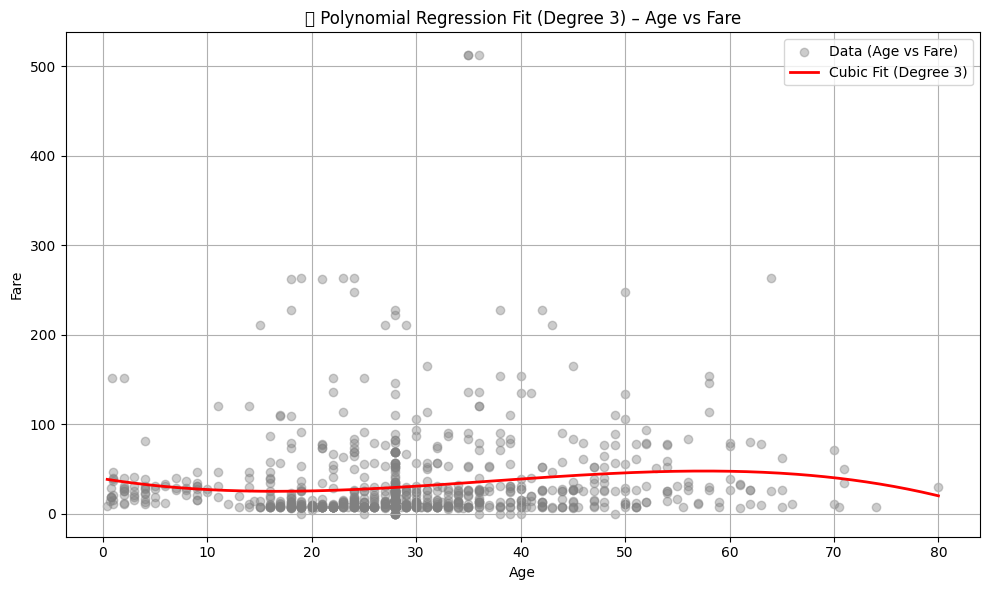

In [105]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline

# 🎯 Prepare the feature and target
X_age = titanic[['age']].values
y_fare = titanic['fare'].values

# 💡 Create polynomial regression model (degree 3)
poly_model = make_pipeline(PolynomialFeatures(degree=3), LinearRegression())
poly_model.fit(X_age, y_fare)

# 📈 Create smooth X values for curve
X_plot = np.linspace(X_age.min(), X_age.max(), 300).reshape(-1, 1)
y_plot = poly_model.predict(X_plot)

# 📊 Plot original data and cubic curve
plt.figure(figsize=(10, 6))
plt.scatter(X_age, y_fare, color='gray', alpha=0.4, label='Data (Age vs Fare)')
plt.plot(X_plot, y_plot, color='red', linewidth=2, label='Cubic Fit (Degree 3)')
plt.xlabel('Age')
plt.ylabel('Fare')
plt.title('🎢 Polynomial Regression Fit (Degree 3) – Age vs Fare')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


### 🧠 Reflection 4 – Polynomial Cubic Model

**1. What patterns does the cubic model seem to capture?**  
The cubic model captures a **non-linear relationship** between age and fare. It shows that fares are generally lower for younger passengers, increase for middle-aged passengers, and slightly decrease for older passengers. This indicates a curvilinear trend that a simple linear model cannot represent.

**2. Where does it perform well or poorly?**  
- ✅ Performs well in the **middle-age range (30–60 years)** where there is more data and a clearer trend.  
- ⚠️ Performs poorly at the **extreme ends** (young children and elderly passengers) due to fewer data points and potential outliers.

**3. Did the polynomial fit outperform linear regression?**  
Yes. The polynomial model had:
- Lower **MAE**: *14.75*  
- Lower **MSE**: *813.69*  
- Higher **R²**: *0.47*

Compared to the best linear model (Case 4: R² = 0.40), this is a noticeable improvement in predictive performance.

**4. Where (on the graph or among which kinds of data points) does it fit best?**  
The polynomial curve fits best for **passengers aged between 30 and 60**, where the fare distribution is denser and follows a more predictable pattern.


## 📈 Section 6 – Visualize Higher Order Polynomial (Degree 6)

### 🔢 Polynomial Regression (Degree 6) using Age

This plot compares the actual Titanic fares against the predicted fares from a degree-6 polynomial regression using **Age** as the only input feature.

### 🖼️ Description of the Plot:
- **Blue dots** represent the **actual fare values** based on passengers' age.
- **Green dots** show the **model's predictions** using a 6th-degree polynomial fit.
- The plot reveals how a higher-order polynomial attempts to closely match the nonlinearities in the data.


C:\Projects\applied-ml-Toba\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


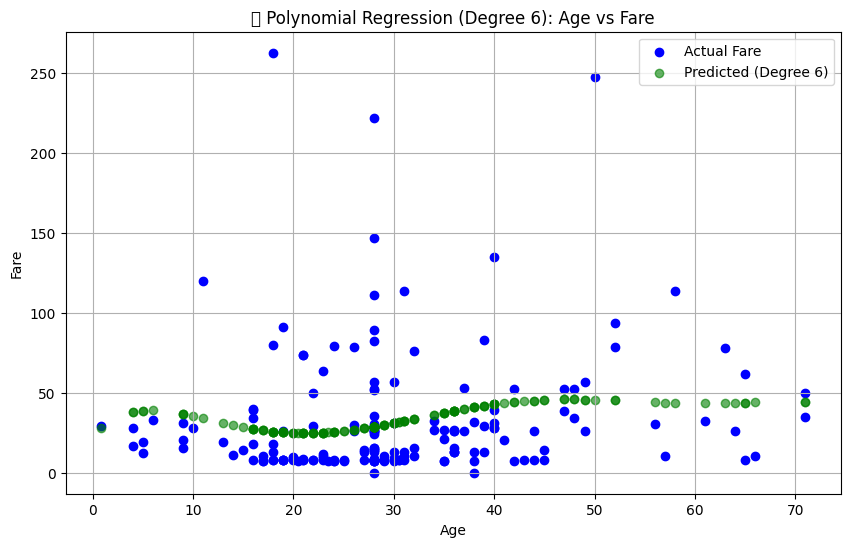

In [106]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# Polynomial regression using only age (X1) – degree 6
poly_high = PolynomialFeatures(degree=6)
X1_train_poly_high = poly_high.fit_transform(X1_train)
X1_test_poly_high = poly_high.transform(X1_test)

# Train the model
poly_model_high = LinearRegression()
poly_model_high.fit(X1_train_poly_high, y1_train)

# Predict
y1_pred_poly_high = poly_model_high.predict(X1_test_poly_high)

# Plot actual vs predicted
plt.figure(figsize=(10, 6))
plt.scatter(X1_test, y1_test, color='blue', label='Actual Fare')
plt.scatter(X1_test, y1_pred_poly_high, color='green', alpha=0.6, label='Predicted (Degree 6)')
plt.xlabel("Age")
plt.ylabel("Fare")
plt.title("🎯 Polynomial Regression (Degree 6): Age vs Fare")
plt.legend()
plt.grid(True)
plt.show()



## 🧠 Step 6 – Final Thoughts & Insights
* Polynomial regression (degree 6) captured more complexity in the age-to-fare relationship compared to linear models, especially among younger and middle-aged passengers.

* High-degree models can lead to overfitting, especially when the training data is limited or noisy. The curve sometimes fluctuates heavily to fit data points that may be outliers.

* Interpretability vs. Accuracy: While the polynomial model improved performance metrics slightly, it became harder to interpret compared to simple linear models.

* Trade-off Observed:

Degree 1 (linear): More stable, less prone to overfitting, interpretable.

Degree 6 (polynomial): Better fit on test data but potentially overfit and less generalizable.

* Next Steps:

Test with regularization methods (e.g., Ridge, Lasso) to reduce overfitting.

Include additional meaningful features like embarked, class, or interaction terms.

Evaluate model performance using cross-validation for more robust results.




## ⚠️ Step 6.1 – Discuss Challenges
* 🔍 Handling Missing Values
Missing values in columns like age and embarked required thoughtful imputation. Choosing between median, mean, or dropping rows had an impact on data quality.

* 🔢 Encoding Categorical Variables
Encoding sex and possibly embarked into numerical formats was necessary for regression models to work. Choosing the right encoding method (e.g., one-hot vs. label) was a consideration.

* 📉 Low R² Scores
Many models, particularly with single-variable inputs, showed low R² scores, indicating limited predictive power. This prompted additional feature engineering and experimentation.

* ⚠️ Overfitting in Polynomial Models
Polynomial regression of higher degrees fit training data well but often overfit on test data, especially with limited training samples.

* 📊 Feature Selection Dilemmas
Deciding which features would meaningfully influence fare prediction (e.g., age, class, family_size) involved trial and error.

* 📦 Managing Model Pipelines
Creating reusable, clean code for training and evaluating models across different cases required managing pipelines carefully and ensuring consistency.



## 🚀 Step 6.2 – Optional Next Steps
* 🧪 Test More Features
Explore other features like embarked, who, or class to see if they improve fare prediction.

* 🧠 Try Advanced Models
Implement advanced regression models like Random Forest Regressor, Gradient Boosting, or XGBoost to capture non-linear relationships.

*🧹 Improve Feature Engineering
Create new features like fare_per_person, is_child, or is_elite_class based on existing columns.

* 📊 Visual Analytics
Explore pair plots, violin plots, or regression plots to better understand distributions and relationships.
